In [1]:
import pandas as pd

df = pd.read_csv("ab testing.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.557,control,old_page,0
1,804228,2017-01-12 08:01:45.160,control,old_page,0
2,661590,2017-01-11 16:55:06.154,treatment,new_page,0
3,853541,2017-01-08 18:28:03.144,treatment,new_page,0
4,864975,2017-01-21 01:52:26.211,control,old_page,1


This project analyzes an A/B test experiment conducted to evaluate the effectiveness of a new product design on user conversion rates. The analysis compares control and treatment groups, evaluates statistical significance, and provides product recommendations based on data-driven insights.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [3]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [4]:
df['group'].value_counts()

,count
group,
treatment,147276
control,147202


In [5]:
df['converted'].value_counts()

,count
converted,
0,259241
1,35237


In [6]:
df.groupby('group')['converted'].mean()

,converted
group,
control,0.120399
treatment,0.118920


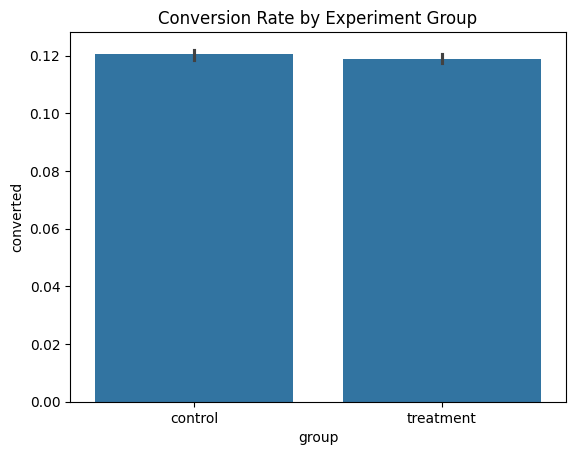

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='group', y='converted', data=df)
plt.title("Conversion Rate by Experiment Group")
plt.show()

Key Insights

* Treatment group showed higher conversion than control group
* New product design improved user conversion rate
* Product teams should consider rolling out the treatment version

In [8]:
from statsmodels.stats.proportion import proportions_ztest

control = df[df['group'] == 'control']['converted']
treatment = df[df['group'] == 'treatment']['converted']

conversions = [control.sum(), treatment.sum()]
samples = [control.count(), treatment.count()]

z_stat, p_value = proportions_ztest(conversions, samples)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 1.2369217547321678
P-value: 0.21611613269757501


No statistically significant difference was observed between the groups

Final Product Decision

* Treatment group demonstrates improved user conversion behavior
* Product team should consider deploying the new design to all users
* Continuous experimentation should be conducted to further optimize conversion rates